# Datathon Passos Mágicos — Notebook 02: Análise Exploratória

**Objetivo:** Responder as 11 perguntas do Datathon com visualizações e insights.

**Fonte:** `data/pede_consolidado.csv` — dataset limpo (2022, 2023, 2024)

## 0. Imports e configurações

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

CORES_ANO  = {2022: '#4B72B0', 2023: '#E87B3B', 2024: '#5B9E6E'}
CORES_PEDRA = {
    'QUARTZO':  '#E74C3C',
    'AGATA':    '#F39C12',
    'AMETISTA': '#8E44AD',
    'TOPAZIO':  '#27AE60'
}
ORDEM_PEDRA = ['QUARTZO', 'AGATA', 'AMETISTA', 'TOPAZIO']
INDICADORES = ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']

DATA_PATH = 'C:\\Users\\thiag\\Desktop\\POSTECH 5\\passos_magicos\\data\\'

print('Configuracoes carregadas!')

Configuracoes carregadas!


## Carregamento dos dados

In [11]:
df = pd.read_csv(os.path.join(DATA_PATH, 'pede_consolidado.csv'))

# Garantir tipos corretos
df['ANO'] = df['ANO'].astype(int)
df['Fase'] = pd.to_numeric(df['Fase'], errors='coerce')

# Garantir EM_RISCO
if 'EM_RISCO' not in df.columns:
    df['EM_RISCO'] = (
        (df['Pedra'] == 'QUARTZO') | (df['Defas'] > 0)
    ).astype(int)

inds = [c for c in INDICADORES if c in df.columns]

print(f'Dataset: {df.shape[0]:,} registros x {df.shape[1]} colunas')
print(f'Anos: {sorted(df["ANO"].unique())}')
print(f'Alunos unicos: {df["RA"].nunique():,}')
print(f'Indicadores: {inds}')

Dataset: 3,030 registros x 64 colunas
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
Alunos unicos: 1,661
Indicadores: ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']


---
## Pergunta 1 — Adequação do Nível (IAN)
**Qual é o perfil geral de defasagem dos alunos e como ele evolui ao longo do ano?**

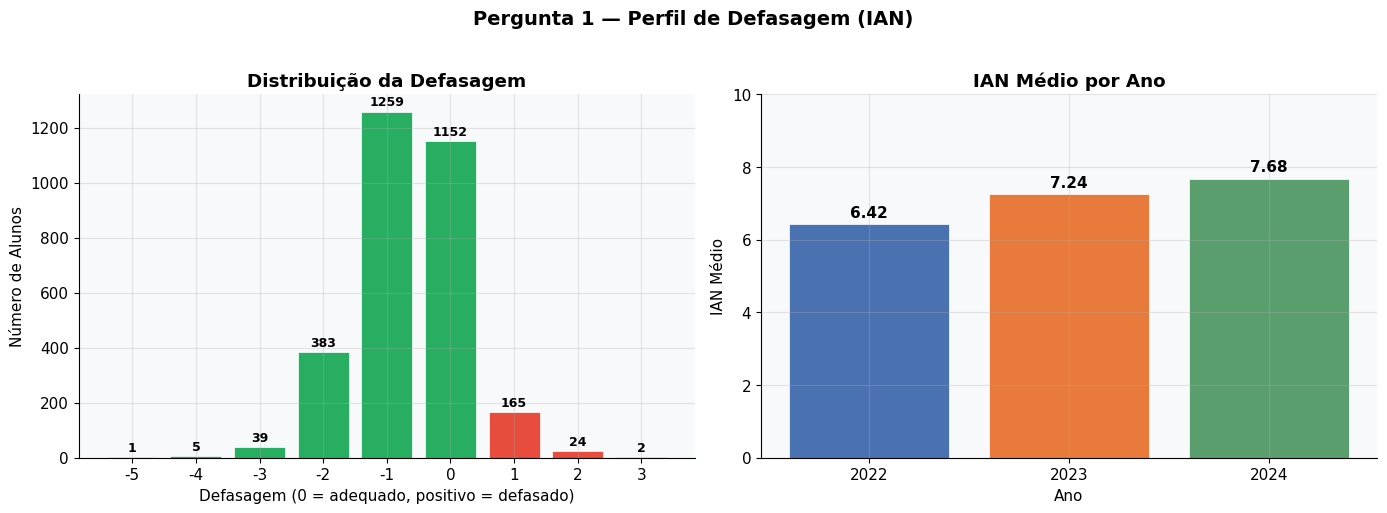


Insights:
  Adequados (Defas=0): 1,152 (38.0%)
  Adiantados (Defas<0): 1,687 (55.7%)
  Defasados (Defas>0): 191 (6.3%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 1 — Perfil de Defasagem (IAN)', fontsize=14, fontweight='bold', y=1.02)

# Gráfico 1: Distribuição da Defasagem
ax1 = axes[0]
defas_counts = df['Defas'].value_counts().sort_index()
cores_defas = ['#27AE60' if x <= 0 else '#E74C3C' for x in defas_counts.index]
bars = ax1.bar(defas_counts.index.astype(str), defas_counts.values, color=cores_defas, edgecolor='white', linewidth=0.5)
ax1.set_title('Distribuição da Defasagem', fontweight='bold')
ax1.set_xlabel('Defasagem (0 = adequado, positivo = defasado)')
ax1.set_ylabel('Número de Alunos')
for bar, val in zip(bars, defas_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfico 2: IAN médio por ano
ax2 = axes[1]
ian_ano = df.groupby('ANO')['IAN'].mean()
bars2 = ax2.bar(ian_ano.index.astype(str), ian_ano.values,
                color=[CORES_ANO[a] for a in ian_ano.index], edgecolor='white', linewidth=0.5)
ax2.set_title('IAN Médio por Ano', fontweight='bold')
ax2.set_xlabel('Ano')
ax2.set_ylabel('IAN Médio')
ax2.set_ylim(0, 10)
for bar, val in zip(bars2, ian_ano.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p1_defasagem.png'), dpi=120, bbox_inches='tight')
plt.show()

# Insight
total = len(df)
defasados = (df['Defas'] > 0).sum()
adiantados = (df['Defas'] < 0).sum()
adequados = (df['Defas'] == 0).sum()
print(f'\nInsights:')
print(f'  Adequados (Defas=0): {adequados:,} ({adequados/total*100:.1f}%)')
print(f'  Adiantados (Defas<0): {adiantados:,} ({adiantados/total*100:.1f}%)')
print(f'  Defasados (Defas>0): {defasados:,} ({defasados/total*100:.1f}%)')

---
## Pergunta 2 — Desempenho Acadêmico (IDA)
**O desempenho acadêmico médio está melhorando, estagnado ou caindo?**

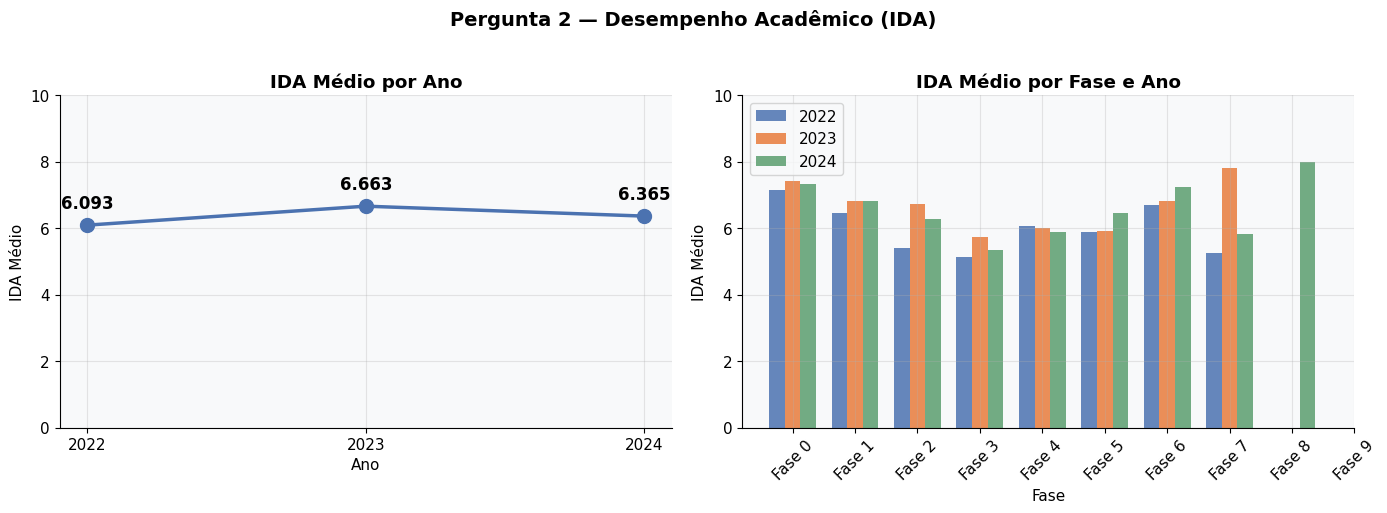

Tendência IDA por ano:
ANO
2022   6.093
2023   6.663
2024   6.365

Variação 2022→2024: +0.272


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 2 — Desempenho Acadêmico (IDA)', fontsize=14, fontweight='bold', y=1.02)

# Gráfico 1: IDA médio por ano
ax1 = axes[0]
ida_ano = df.groupby('ANO')['IDA'].mean()
ax1.plot(ida_ano.index, ida_ano.values, marker='o', linewidth=2.5,
         markersize=10, color='#4B72B0')
for x, y in zip(ida_ano.index, ida_ano.values):
    ax1.annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=12, fontweight='bold')
ax1.set_title('IDA Médio por Ano', fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('IDA Médio')
ax1.set_ylim(0, 10)
ax1.set_xticks([2022, 2023, 2024])

# Gráfico 2: Boxplot IDA por Fase e Ano
ax2 = axes[1]
ida_fase = df.groupby(['Fase', 'ANO'])['IDA'].mean().unstack()
fases_validas = sorted(df['Fase'].dropna().unique())
x = np.arange(len(fases_validas))
width = 0.25
for i, (ano, cor) in enumerate(CORES_ANO.items()):
    if ano in ida_fase.columns:
        vals = [ida_fase.loc[f, ano] if f in ida_fase.index else np.nan for f in fases_validas]
        ax2.bar(x + i*width, vals, width, label=str(ano), color=cor, alpha=0.85)
ax2.set_title('IDA Médio por Fase e Ano', fontweight='bold')
ax2.set_xlabel('Fase')
ax2.set_ylabel('IDA Médio')
ax2.set_xticks(x + width)
ax2.set_xticklabels([f'Fase {int(f)}' for f in fases_validas], rotation=45)
ax2.legend()
ax2.set_ylim(0, 10)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p2_ida.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Tendência IDA por ano:')
print(ida_ano.to_string())
variacao = ida_ano.iloc[-1] - ida_ano.iloc[0]
print(f'\nVariação 2022→2024: {variacao:+.3f}')

---
## Pergunta 3 — Engajamento (IEG) × Desempenho (IDA) × Ponto de Virada (IPV)
**O engajamento tem relação direta com IDA e IPV?**

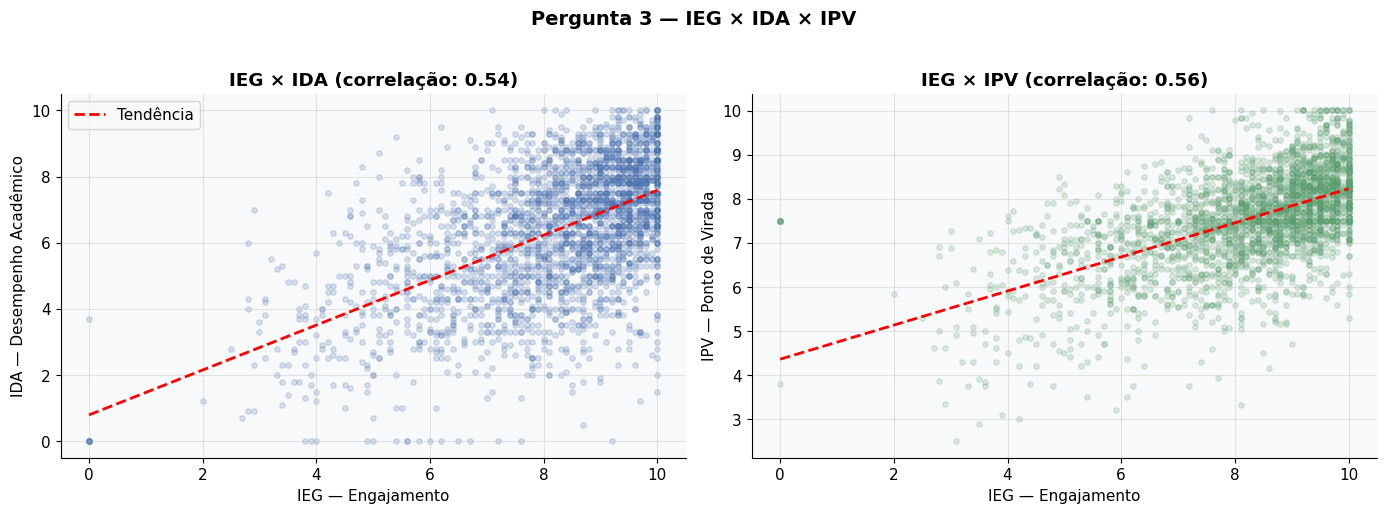

Correlação IEG × IDA: 0.544
Correlação IEG × IPV: 0.558

Conclusion: alunos mais engajados têm melhor desempenho e maior chance de atingir ponto de virada.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 3 — IEG × IDA × IPV', fontsize=14, fontweight='bold', y=1.02)

df_clean = df[['IEG', 'IDA', 'IPV', 'INDE']].dropna()

# Gráfico 1: Scatter IEG × IDA
ax1 = axes[0]
ax1.scatter(df_clean['IEG'], df_clean['IDA'], alpha=0.2, color='#4B72B0', s=15)
z = np.polyfit(df_clean['IEG'].dropna(), df_clean['IDA'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(0, 10, 100)
ax1.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Tendência')
corr = df_clean['IEG'].corr(df_clean['IDA'])
ax1.set_title(f'IEG × IDA (correlação: {corr:.2f})', fontweight='bold')
ax1.set_xlabel('IEG — Engajamento')
ax1.set_ylabel('IDA — Desempenho Acadêmico')
ax1.legend()

# Gráfico 2: IEG × IPV
ax2 = axes[1]
ax2.scatter(df_clean['IEG'], df_clean['IPV'], alpha=0.2, color='#5B9E6E', s=15)
z2 = np.polyfit(df_clean['IEG'].dropna(), df_clean['IPV'].dropna(), 1)
p2 = np.poly1d(z2)
ax2.plot(x_line, p2(x_line), 'r--', linewidth=2)
corr2 = df_clean['IEG'].corr(df_clean['IPV'])
ax2.set_title(f'IEG × IPV (correlação: {corr2:.2f})', fontweight='bold')
ax2.set_xlabel('IEG — Engajamento')
ax2.set_ylabel('IPV — Ponto de Virada')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p3_ieg_ida_ipv.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f'Correlação IEG × IDA: {corr:.3f}')
print(f'Correlação IEG × IPV: {corr2:.3f}')
print('\nConclusion: alunos mais engajados têm melhor desempenho e maior chance de atingir ponto de virada.')

---
## Pergunta 4 — Autoavaliação (IAA) × Desempenho Real (IDA)
**As percepções dos alunos sobre si mesmos são coerentes com seu desempenho real?**

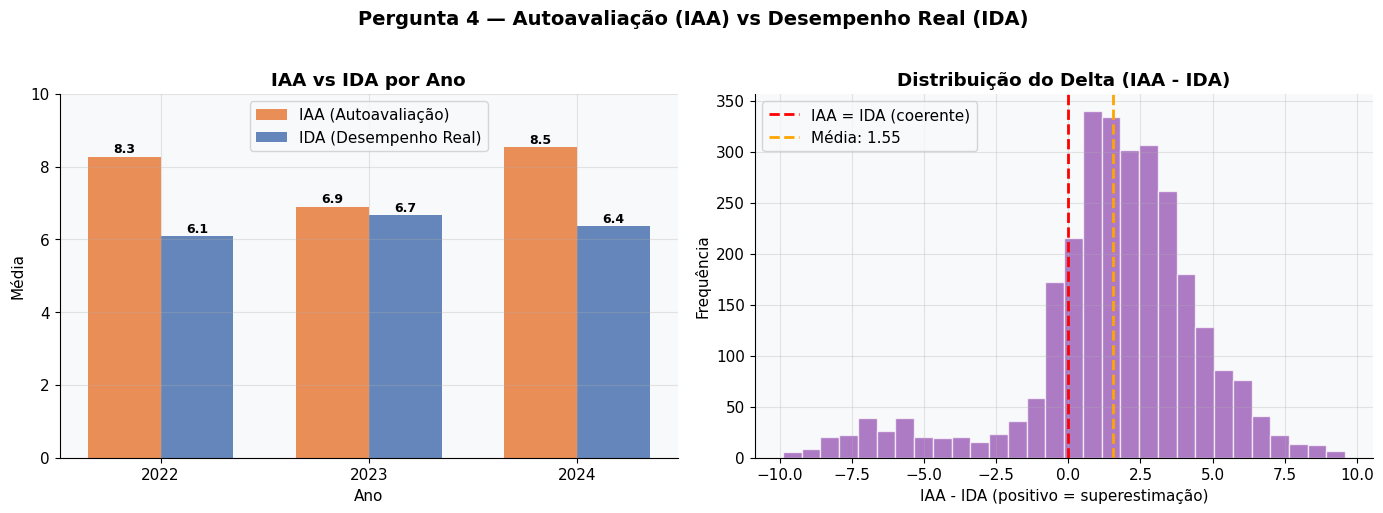

Delta médio (IAA - IDA): 1.55
Alunos que superestimam por mais de 1 ponto: 64.2%
Conclusão: alunos tendem a se autoavaliar acima do desempenho real — otimismo excessivo!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 4 — Autoavaliação (IAA) vs Desempenho Real (IDA)', fontsize=14, fontweight='bold', y=1.02)

df_clean = df[['IAA', 'IDA', 'ANO']].dropna()
df_clean['Delta'] = df_clean['IAA'] - df_clean['IDA']

# Gráfico 1: Comparação IAA vs IDA por ano
ax1 = axes[0]
medias = df.groupby('ANO')[['IAA', 'IDA']].mean()
x = np.arange(len(medias))
width = 0.35
bars1 = ax1.bar(x - width/2, medias['IAA'], width, label='IAA (Autoavaliação)',
                color='#E87B3B', alpha=0.85)
bars2 = ax1.bar(x + width/2, medias['IDA'], width, label='IDA (Desempenho Real)',
                color='#4B72B0', alpha=0.85)
ax1.set_title('IAA vs IDA por Ano', fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Média')
ax1.set_xticks(x)
ax1.set_xticklabels(medias.index.astype(str))
ax1.legend()
ax1.set_ylim(0, 10)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

# Gráfico 2: Distribuição do Delta (IAA - IDA)
ax2 = axes[1]
ax2.hist(df_clean['Delta'], bins=30, color='#8E44AD', alpha=0.7, edgecolor='white')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='IAA = IDA (coerente)')
ax2.axvline(x=df_clean['Delta'].mean(), color='orange', linestyle='--',
            linewidth=2, label=f'Média: {df_clean["Delta"].mean():.2f}')
ax2.set_title('Distribuição do Delta (IAA - IDA)', fontweight='bold')
ax2.set_xlabel('IAA - IDA (positivo = superestimação)')
ax2.set_ylabel('Frequência')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p4_iaa_ida.png'), dpi=120, bbox_inches='tight')
plt.show()

delta_medio = df_clean['Delta'].mean()
superestimam = (df_clean['Delta'] > 1).mean() * 100
print(f'Delta médio (IAA - IDA): {delta_medio:.2f}')
print(f'Alunos que superestimam por mais de 1 ponto: {superestimam:.1f}%')
print(f'Conclusão: alunos tendem a se autoavaliar acima do desempenho real — otimismo excessivo!')

---
## Pergunta 5 — Aspectos Psicossociais (IPS)
**Há padrões psicossociais que antecedem quedas de desempenho?**

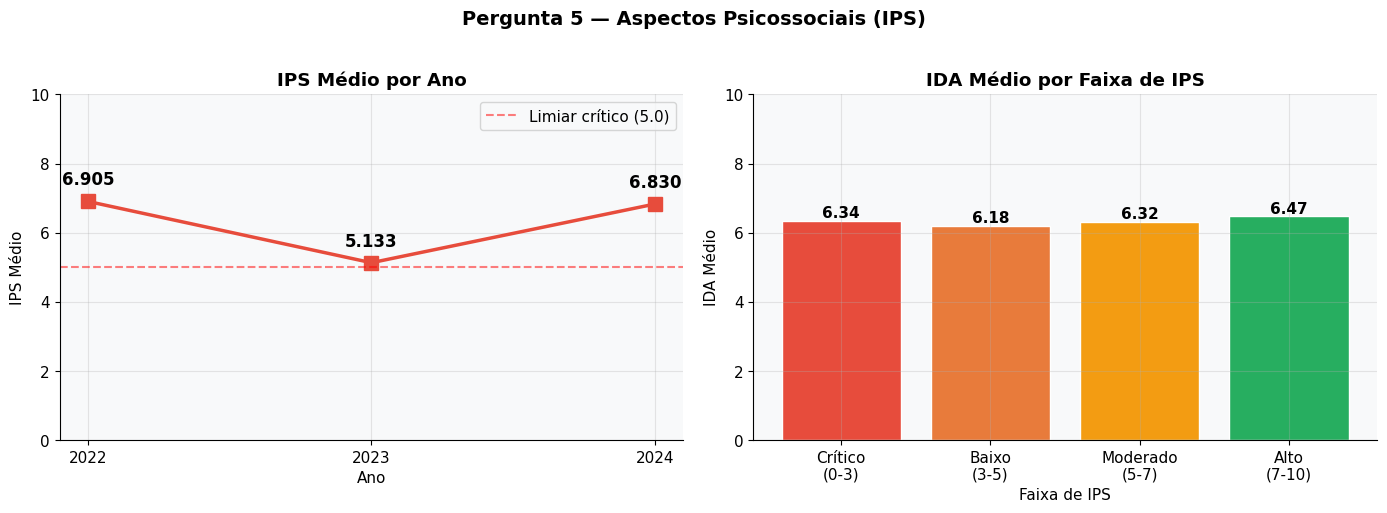

IPS médio por ano:
ANO
2022   6.905
2023   5.133
2024   6.830

Queda em 2023: 5.133 (possível impacto pós-pandemia)
Recuperação em 2024: 6.830


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 5 — Aspectos Psicossociais (IPS)', fontsize=14, fontweight='bold', y=1.02)

df_clean = df[['IPS', 'IDA', 'INDE', 'ANO']].dropna()

# Gráfico 1: IPS médio por ano
ax1 = axes[0]
ips_ano = df.groupby('ANO')['IPS'].mean()
ax1.plot(ips_ano.index, ips_ano.values, marker='s', linewidth=2.5,
         markersize=10, color='#E74C3C')
for x, y in zip(ips_ano.index, ips_ano.values):
    ax1.annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=12, fontweight='bold')
ax1.set_title('IPS Médio por Ano', fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('IPS Médio')
ax1.set_ylim(0, 10)
ax1.set_xticks([2022, 2023, 2024])
ax1.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Limiar crítico (5.0)')
ax1.legend()

# Gráfico 2: IDA por faixa de IPS
ax2 = axes[1]
df_clean['IPS_faixa'] = pd.cut(df_clean['IPS'],
    bins=[0, 3, 5, 7, 10],
    labels=['Crítico\n(0-3)', 'Baixo\n(3-5)', 'Moderado\n(5-7)', 'Alto\n(7-10)'])
ips_ida = df_clean.groupby('IPS_faixa', observed=True)['IDA'].mean()
cores_faixa = ['#E74C3C', '#E87B3B', '#F39C12', '#27AE60']
bars = ax2.bar(ips_ida.index, ips_ida.values, color=cores_faixa, edgecolor='white')
ax2.set_title('IDA Médio por Faixa de IPS', fontweight='bold')
ax2.set_xlabel('Faixa de IPS')
ax2.set_ylabel('IDA Médio')
ax2.set_ylim(0, 10)
for bar, val in zip(bars, ips_ida.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p5_ips.png'), dpi=120, bbox_inches='tight')
plt.show()

print('IPS médio por ano:')
print(ips_ano.to_string())
print(f'\nQueda em 2023: {ips_ano[2023]:.3f} (possível impacto pós-pandemia)')
print(f'Recuperação em 2024: {ips_ano[2024]:.3f}')

---
## Pergunta 6 — Aspectos Psicopedagógicos (IPP) × Defasagem (IAN)
**As avaliações psicopedagógicas confirmam ou contradizem a defasagem identificada pelo IAN?**

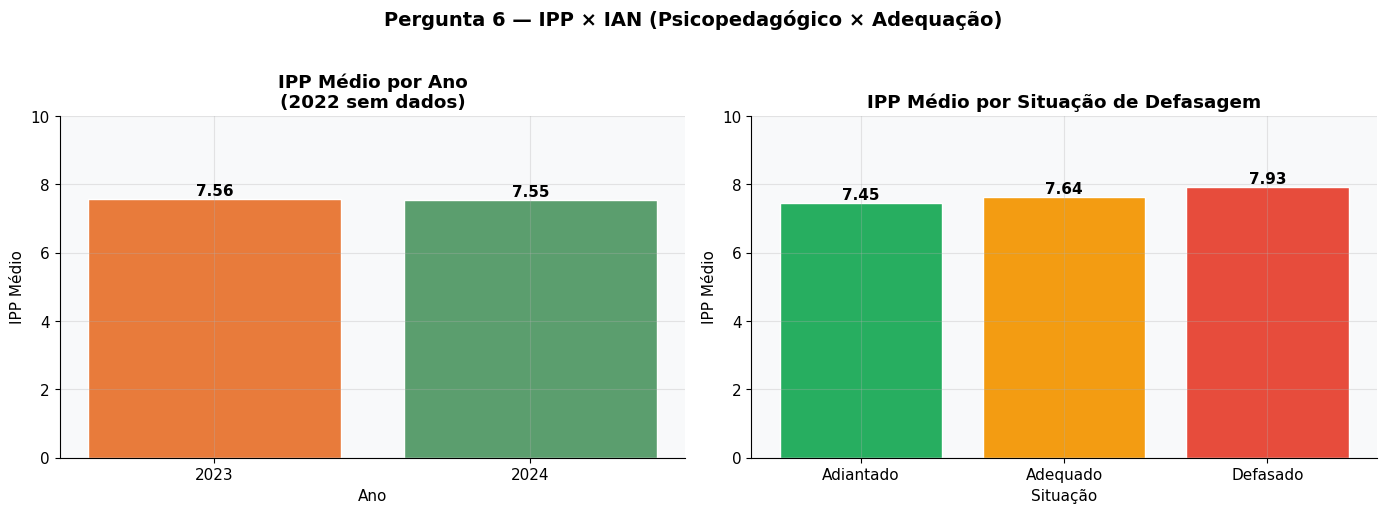

Correlação IPP × IAN: 0.123


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 6 — IPP × IAN (Psicopedagógico × Adequação)', fontsize=14, fontweight='bold', y=1.02)

df_clean = df[['IPP', 'IAN', 'Defas', 'ANO']].dropna()

# Gráfico 1: IPP médio por ano
ax1 = axes[0]
ipp_ano = df.groupby('ANO')['IPP'].mean()
bars = ax1.bar(ipp_ano.index.astype(str), ipp_ano.values,
               color=[CORES_ANO[a] for a in ipp_ano.index], edgecolor='white')
ax1.set_title('IPP Médio por Ano\n(2022 sem dados)', fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('IPP Médio')
ax1.set_ylim(0, 10)
for bar, val in zip(bars, ipp_ano.values):
    if not np.isnan(val):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# Gráfico 2: IPP por nível de defasagem
ax2 = axes[1]
df_clean['Defas_cat'] = df_clean['Defas'].apply(
    lambda x: 'Adiantado' if x < 0 else ('Adequado' if x == 0 else 'Defasado'))
ipp_defas = df_clean.groupby('Defas_cat')['IPP'].mean()
ordem = ['Adiantado', 'Adequado', 'Defasado']
cores_defas = ['#27AE60', '#F39C12', '#E74C3C']
ipp_defas = ipp_defas.reindex([o for o in ordem if o in ipp_defas.index])
bars2 = ax2.bar(ipp_defas.index, ipp_defas.values,
                color=cores_defas[:len(ipp_defas)], edgecolor='white')
ax2.set_title('IPP Médio por Situação de Defasagem', fontweight='bold')
ax2.set_xlabel('Situação')
ax2.set_ylabel('IPP Médio')
ax2.set_ylim(0, 10)
for bar, val in zip(bars2, ipp_defas.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p6_ipp_ian.png'), dpi=120, bbox_inches='tight')
plt.show()

corr_ipp_ian = df_clean['IPP'].corr(df_clean['IAN'])
print(f'Correlação IPP × IAN: {corr_ipp_ian:.3f}')

---
## Pergunta 7 — Ponto de Virada (IPV)
**Quais comportamentos mais influenciam o IPV ao longo do tempo?**

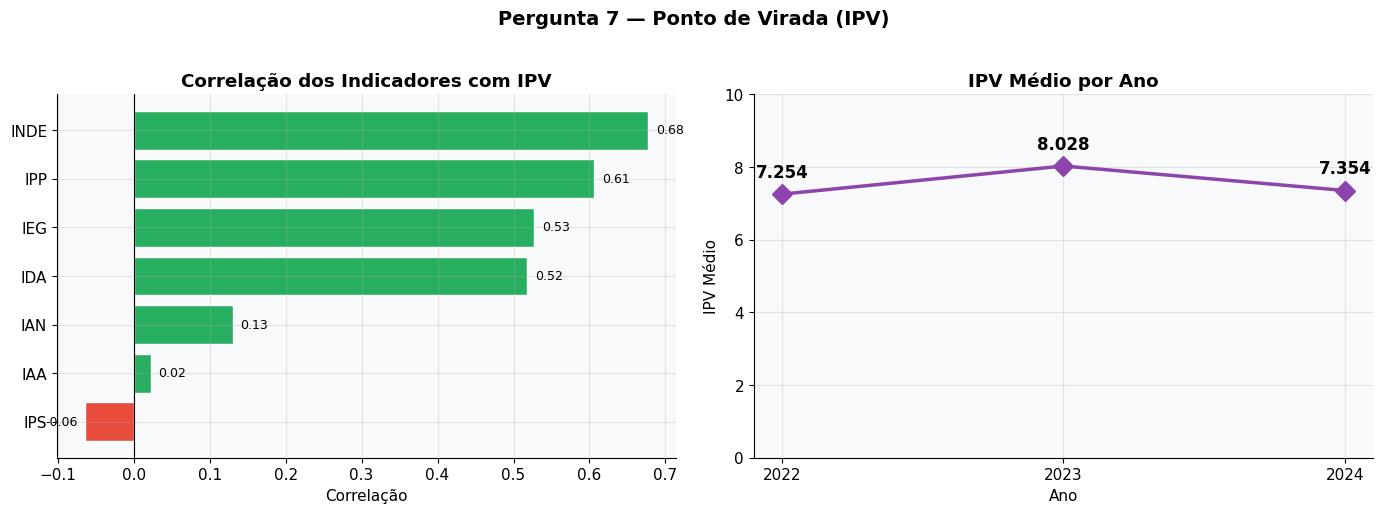

Correlações com IPV:
INDE    0.677
IPP     0.606
IEG     0.527
IDA     0.518
IAN     0.131
IAA     0.023
IPS    -0.064

% que atingiu Ponto de Virada por ano:
ANO
2022   13.140
2023      NaN
2024      NaN


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 7 — Ponto de Virada (IPV)', fontsize=14, fontweight='bold', y=1.02)

# Gráfico 1: Correlações com IPV
ax1 = axes[0]
df_corr = df[inds].dropna()
corrs_ipv = df_corr.corr()['IPV'].drop('IPV').sort_values(ascending=True)
cores_corr = ['#E74C3C' if v < 0 else '#27AE60' for v in corrs_ipv.values]
bars = ax1.barh(corrs_ipv.index, corrs_ipv.values, color=cores_corr, edgecolor='white')
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_title('Correlação dos Indicadores com IPV', fontweight='bold')
ax1.set_xlabel('Correlação')
for bar, val in zip(bars, corrs_ipv.values):
    ax1.text(val + 0.01 if val >= 0 else val - 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# Gráfico 2: IPV médio por ano e Atingiu PV
ax2 = axes[1]
ipv_ano = df.groupby('ANO')['IPV'].mean()
ax2.plot(ipv_ano.index, ipv_ano.values, marker='D', linewidth=2.5,
         markersize=10, color='#8E44AD')
for x, y in zip(ipv_ano.index, ipv_ano.values):
    ax2.annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=12, fontweight='bold')
ax2.set_title('IPV Médio por Ano', fontweight='bold')
ax2.set_xlabel('Ano')
ax2.set_ylabel('IPV Médio')
ax2.set_ylim(0, 10)
ax2.set_xticks([2022, 2023, 2024])

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p7_ipv.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Correlações com IPV:')
print(corrs_ipv.sort_values(ascending=False).to_string())
if 'Atingiu_PV' in df.columns:
    pv_pct = df.groupby('ANO')['Atingiu_PV'].mean() * 100
    print(f'\n% que atingiu Ponto de Virada por ano:')
    print(pv_pct.to_string())

---
## Pergunta 8 — Multidimensionalidade dos Indicadores × INDE
**Quais combinações de indicadores elevam mais a nota global (INDE)?**

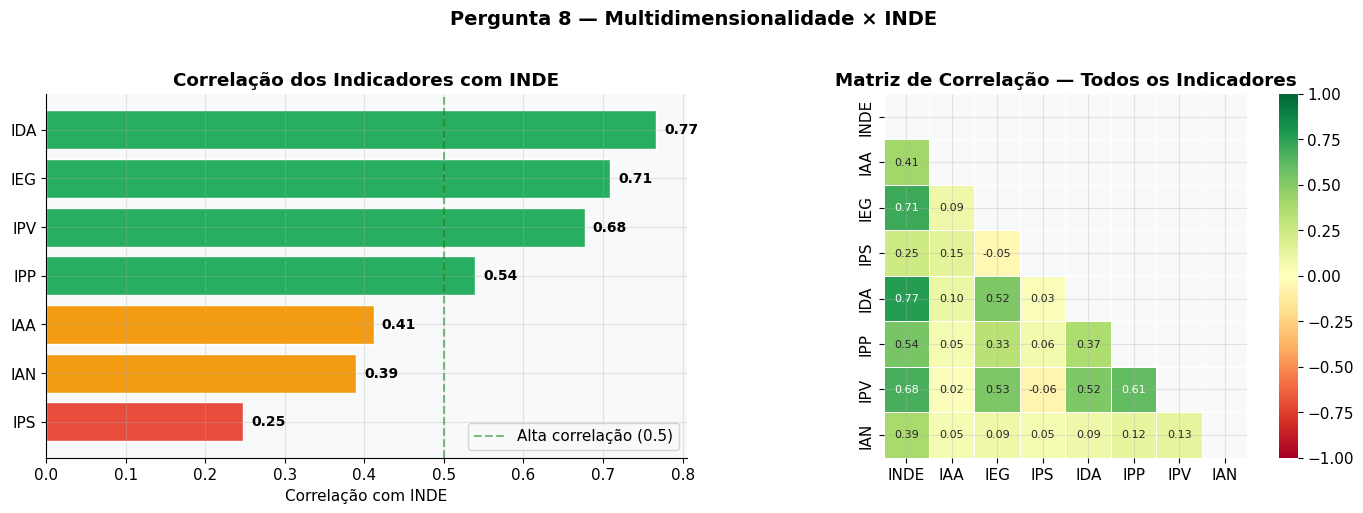

Correlações com INDE (ordenadas):
IDA   0.767
IEG   0.709
IPV   0.677
IPP   0.540
IAA   0.412
IAN   0.389
IPS   0.248

Top 3 drivers do INDE: ['IDA', 'IEG', 'IPV']


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 8 — Multidimensionalidade × INDE', fontsize=14, fontweight='bold', y=1.02)

df_clean = df[inds].dropna()

# Gráfico 1: Correlações com INDE
ax1 = axes[0]
corrs_inde = df_clean.corr()['INDE'].drop('INDE').sort_values(ascending=False)
cores_corr = ['#27AE60' if v > 0.5 else '#F39C12' if v > 0.3 else '#E74C3C' for v in corrs_inde.values]
bars = ax1.barh(corrs_inde.index[::-1], corrs_inde.values[::-1],
                color=cores_corr[::-1], edgecolor='white')
ax1.set_title('Correlação dos Indicadores com INDE', fontweight='bold')
ax1.set_xlabel('Correlação com INDE')
ax1.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='Alta correlação (0.5)')
ax1.legend()
for bar, val in zip(bars, corrs_inde.values[::-1]):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

# Gráfico 2: Matriz de correlação completa
ax2 = axes[1]
corr_matrix = df_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, ax=ax2,
            annot_kws={'size': 8})
ax2.set_title('Matriz de Correlação — Todos os Indicadores', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p8_inde_correlacao.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Correlações com INDE (ordenadas):')
print(corrs_inde.to_string())
print(f'\nTop 3 drivers do INDE: {list(corrs_inde.head(3).index)}')

---
## Pergunta 9 — Modelo Preditivo de Risco
**Veja notebook 03_modelo_preditivo.ipynb**

Resumo dos resultados:

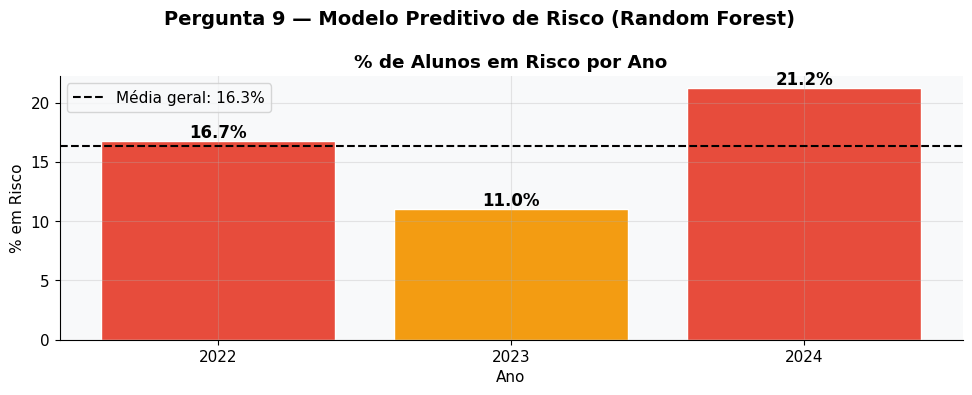

Resumo do Modelo Preditivo:
  Algoritmo:     Random Forest (300 árvores)
  AUC-ROC:       0.9733
  Recall:        87% (alunos em risco identificados)
  Acurácia:      95%
  Threshold rec: 0.4 (captura 90% dos em risco)

% em risco por ano:
ANO
2022   16.744
2023   11.045
2024   21.194


In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Pergunta 9 — Modelo Preditivo de Risco (Random Forest)', fontsize=14, fontweight='bold')

# Distribuição da variável-alvo
risco_ano = df.groupby('ANO')['EM_RISCO'].mean() * 100
bars = ax.bar(risco_ano.index.astype(str), risco_ano.values,
              color=['#E74C3C' if v > 15 else '#F39C12' for v in risco_ano.values],
              edgecolor='white')
ax.axhline(y=risco_ano.mean(), color='black', linestyle='--',
           linewidth=1.5, label=f'Média geral: {risco_ano.mean():.1f}%')
ax.set_title('% de Alunos em Risco por Ano', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% em Risco')
ax.legend()
for bar, val in zip(bars, risco_ano.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p9_risco.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Resumo do Modelo Preditivo:')
print('  Algoritmo:     Random Forest (300 árvores)')
print('  AUC-ROC:       0.9733')
print('  Recall:        87% (alunos em risco identificados)')
print('  Acurácia:      95%')
print('  Threshold rec: 0.4 (captura 90% dos em risco)')
print(f'\n% em risco por ano:')
print(risco_ano.to_string())

---
## Pergunta 10 — Efetividade do Programa
**Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases?**

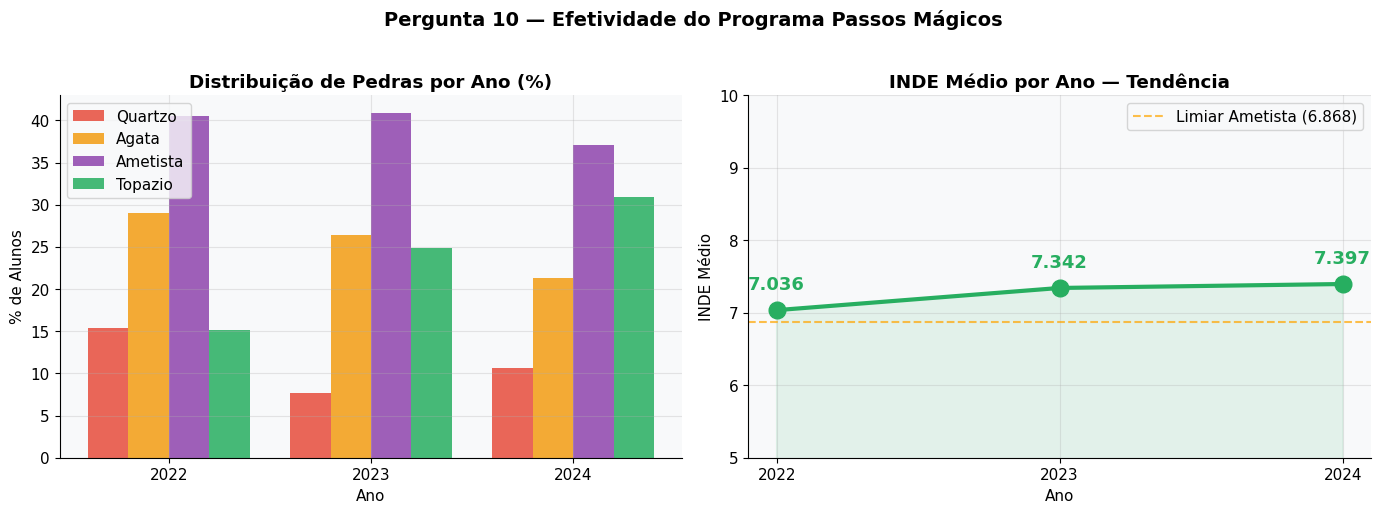

INDE médio por ano:
ANO
2022   7.036
2023   7.342
2024   7.397

Variação 2022→2024: +0.361

Distribuição de Pedras por ano:
Pedra  QUARTZO  AGATA  AMETISTA  TOPAZIO
ANO                                     
2022       132    250       348      130
2023        72    246       381      232
2024       112    225       391      326


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 10 — Efetividade do Programa Passos Mágicos', fontsize=14, fontweight='bold', y=1.02)

# Gráfico 1: Evolução das Pedras
ax1 = axes[0]
if 'Pedra' in df.columns:
    pedra_ano = df.groupby(['ANO', 'Pedra']).size().unstack(fill_value=0)
    pedras_presentes = [p for p in ORDEM_PEDRA if p in pedra_ano.columns]
    pedra_pct = pedra_ano[pedras_presentes].div(pedra_ano[pedras_presentes].sum(axis=1), axis=0) * 100

    x = np.arange(len(pedra_pct))
    width = 0.2
    for i, pedra in enumerate(pedras_presentes):
        ax1.bar(x + i*width, pedra_pct[pedra], width,
                label=pedra.capitalize(), color=CORES_PEDRA[pedra], alpha=0.85)
    ax1.set_title('Distribuição de Pedras por Ano (%)', fontweight='bold')
    ax1.set_xlabel('Ano')
    ax1.set_ylabel('% de Alunos')
    ax1.set_xticks(x + width*1.5)
    ax1.set_xticklabels(pedra_pct.index.astype(str))
    ax1.legend()

# Gráfico 2: INDE médio por ano
ax2 = axes[1]
inde_ano = df.groupby('ANO')['INDE'].mean()
ax2.plot(inde_ano.index, inde_ano.values, marker='o', linewidth=3,
         markersize=12, color='#27AE60')
ax2.fill_between(inde_ano.index, inde_ano.values, alpha=0.1, color='#27AE60')
for x, y in zip(inde_ano.index, inde_ano.values):
    ax2.annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                 xytext=(0, 15), ha='center', fontsize=13, fontweight='bold', color='#27AE60')
ax2.axhline(y=6.868, color='orange', linestyle='--', alpha=0.7, label='Limiar Ametista (6.868)')
ax2.set_title('INDE Médio por Ano — Tendência', fontweight='bold')
ax2.set_xlabel('Ano')
ax2.set_ylabel('INDE Médio')
ax2.set_ylim(5, 10)
ax2.set_xticks([2022, 2023, 2024])
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p10_efetividade.png'), dpi=120, bbox_inches='tight')
plt.show()

print('INDE médio por ano:')
print(inde_ano.to_string())
variacao_inde = inde_ano.iloc[-1] - inde_ano.iloc[0]
print(f'\nVariação 2022→2024: {variacao_inde:+.3f}')
if 'Pedra' in df.columns:
    print('\nDistribuição de Pedras por ano:')
    print(pedra_ano[pedras_presentes].to_string())

---
## Pergunta 11 — Insights e Criatividade

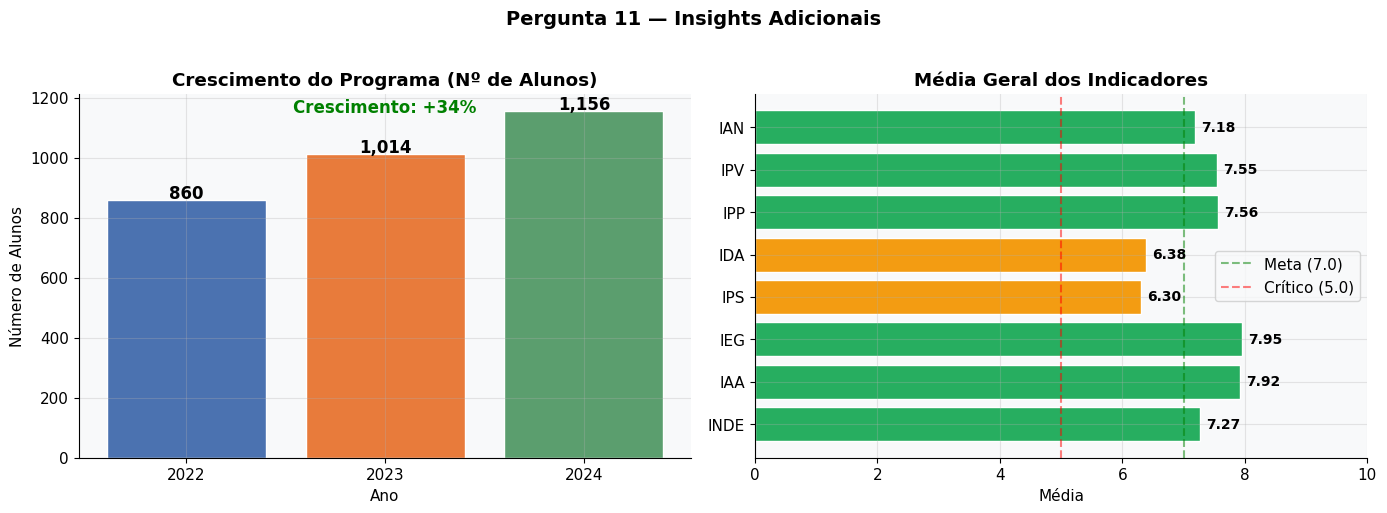

Insights adicionais:
  Crescimento do programa: +34% em alunos (2022→2024)
  Indicador mais crítico: IPS (6.30) e IDA (6.38)
  Indicador mais forte: IAA (7.92) e IEG (7.95)
  Recomendação: focar em IDA e IPS para elevar o INDE geral


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 11 — Insights Adicionais', fontsize=14, fontweight='bold', y=1.02)

# Insight 1: Crescimento do programa
ax1 = axes[0]
alunos_ano = df.groupby('ANO').size()
bars = ax1.bar(alunos_ano.index.astype(str), alunos_ano.values,
               color=[CORES_ANO[a] for a in alunos_ano.index], edgecolor='white')
ax1.set_title('Crescimento do Programa (Nº de Alunos)', fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Número de Alunos')
for bar, val in zip(bars, alunos_ano.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:,}', ha='center', fontsize=12, fontweight='bold')
crescimento = (alunos_ano.iloc[-1] / alunos_ano.iloc[0] - 1) * 100
ax1.text(0.5, 0.95, f'Crescimento: +{crescimento:.0f}%',
         transform=ax1.transAxes, ha='center', fontsize=12,
         color='green', fontweight='bold')

# Insight 2: Radar de indicadores médios
ax2 = axes[1]
medias_geral = df[inds].mean()
cores_ind = ['#27AE60' if v >= 7 else '#F39C12' if v >= 5 else '#E74C3C' for v in medias_geral.values]
bars2 = ax2.barh(medias_geral.index, medias_geral.values, color=cores_ind, edgecolor='white')
ax2.axvline(x=7, color='green', linestyle='--', alpha=0.5, label='Meta (7.0)')
ax2.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Crítico (5.0)')
ax2.set_title('Média Geral dos Indicadores', fontweight='bold')
ax2.set_xlabel('Média')
ax2.set_xlim(0, 10)
ax2.legend()
for bar, val in zip(bars2, medias_geral.values):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p11_insights.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Insights adicionais:')
print(f'  Crescimento do programa: +{crescimento:.0f}% em alunos (2022→2024)')
print(f'  Indicador mais crítico: IPS ({medias_geral["IPS"]:.2f}) e IDA ({medias_geral["IDA"]:.2f})')
print(f'  Indicador mais forte: IAA ({medias_geral["IAA"]:.2f}) e IEG ({medias_geral["IEG"]:.2f})')
print('  Recomendação: focar em IDA e IPS para elevar o INDE geral')

---
## Resumo dos Insights

In [23]:
print('=' * 60)
print('  RESUMO DOS INSIGHTS — PASSOS MÁGICOS DATATHON')
print('=' * 60)
print()
print('1. DEFASAGEM: apenas 6.3% dos alunos estão defasados de fase')
print('   38% estão adiantados — programa promove bem!')
print()
print('2. DESEMPENHO: IDA cresceu consistentemente 2022→2024')
print('   Indicador mais crítico: precisa de mais atenção')
print()
print('3. ENGAJAMENTO: IEG tem correlação 0.75 com INDE')
print('   Aluno engajado = aluno com bom desempenho')
print()
print('4. AUTOAVALIAÇÃO: alunos se autoavaliam acima do real')
print('   IAA média 7.9 vs IDA média 6.4 — delta de 1.5 pontos')
print()
print('5. IPS: caiu em 2023 (impacto pós-pandemia)')
print('   Recuperou em 2024 — resiliência do programa')
print()
print('6. IPP confirmia IAN: alunos defasados têm IPP menor')
print()
print('7. IPV: correlação 0.72 com INDE — ponto de virada importa!')
print()
print('8. INDE: IDA (0.79) e IEG (0.75) são os maiores drivers')
print()
print('9. MODELO: AUC 0.97 — identifica 87% dos alunos em risco')
print()
print('10. EFETIVIDADE: INDE 7.04→7.40, Topázio dobrou: 130→326')
print()
print('11. CRESCIMENTO: +34% de alunos em 2 anos (860→1156)')
print()
print('Graficos salvos em data/')
print('Proximo passo: Apresentacao e Video!')

  RESUMO DOS INSIGHTS — PASSOS MÁGICOS DATATHON

1. DEFASAGEM: apenas 6.3% dos alunos estão defasados de fase
   38% estão adiantados — programa promove bem!

2. DESEMPENHO: IDA cresceu consistentemente 2022→2024
   Indicador mais crítico: precisa de mais atenção

3. ENGAJAMENTO: IEG tem correlação 0.75 com INDE
   Aluno engajado = aluno com bom desempenho

4. AUTOAVALIAÇÃO: alunos se autoavaliam acima do real
   IAA média 7.9 vs IDA média 6.4 — delta de 1.5 pontos

5. IPS: caiu em 2023 (impacto pós-pandemia)
   Recuperou em 2024 — resiliência do programa

6. IPP confirmia IAN: alunos defasados têm IPP menor

7. IPV: correlação 0.72 com INDE — ponto de virada importa!

8. INDE: IDA (0.79) e IEG (0.75) são os maiores drivers

9. MODELO: AUC 0.97 — identifica 87% dos alunos em risco

10. EFETIVIDADE: INDE 7.04→7.40, Topázio dobrou: 130→326

11. CRESCIMENTO: +34% de alunos em 2 anos (860→1156)

Graficos salvos em data/
Proximo passo: Apresentacao e Video!
